In [1]:
# IMPORT LIBRARY

import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

from sklearn.metrics import classification_report, confusion_matrix

In [2]:
from google.colab import drive
drive.mount('/content/drive')

# DEFINISIKAN PATH DATASET DISIMPAN
dataset_path = "/content/drive/MyDrive/UAS_VANISSA-KBL91/UAS-kaggel"

train_dir = dataset_path + "/train"
valid_dir = dataset_path + "/valid"
test_dir = dataset_path + "/test"

print("=" * 50)
print("DATASET BERHASIL DIMUAT")
print("=" * 50)
print("Train      :", train_dir)
print("Validation :", valid_dir)
print("Test       :", test_dir)
print("=" * 50)

Mounted at /content/drive
DATASET BERHASIL DIMUAT
Train      : /content/drive/MyDrive/UAS_VANISSA-KBL91/UAS-kaggel/train
Validation : /content/drive/MyDrive/UAS_VANISSA-KBL91/UAS-kaggel/valid
Test       : /content/drive/MyDrive/UAS_VANISSA-KBL91/UAS-kaggel/test


In [3]:
# EXPLORATORY DATA ANALYSIS (EDA)
import os
import pandas as pd

# Menghitung jumlah kelas
classes = sorted(os.listdir(train_dir))
num_classes = len(classes)

# Menghitung jumlah gambar
train_total = 0
valid_total = 0
test_total = 0

class_distribution = []

for cls in classes:
    train_count = len(os.listdir(os.path.join(train_dir, cls)))
    valid_count = len(os.listdir(os.path.join(valid_dir, cls)))
    test_count = len(os.listdir(os.path.join(test_dir, cls)))
    train_total += train_count
    valid_total += valid_count
    test_total += test_count
    class_distribution.append([
        cls,
        train_count,
        valid_count,
        test_count,
        train_count + valid_count + test_count
    ])

total_images = train_total + valid_total + test_total

print("=" * 50)
print("INFORMASI DATASET")
print("=" * 50)
print(f"Jumlah Kelas      : {num_classes}")
print(f"Jumlah Train      : {train_total}")
print(f"Jumlah Validation : {valid_total}")
print(f"Jumlah Test       : {test_total}")
print(f"Total Gambar      : {total_images}")
print("=" * 50)

distribution_df = pd.DataFrame(
    class_distribution,columns=[
        "Class",
        "Train",
        "Validation",
        "Test",
        "Total"
    ]
)

distribution_df.head()

INFORMASI DATASET
Jumlah Kelas      : 100
Jumlah Train      : 12610
Jumlah Validation : 500
Jumlah Test       : 500
Total Gambar      : 13610


,Class,Train,Validation,Test,Total
0,ADONIS,126,5,5,136
1,AFRICAN GIANT SWALLOWTAIL,107,5,5,117
2,AMERICAN SNOOT,105,5,5,115
3,AN 88,121,5,5,131
4,APPOLLO,128,5,5,138


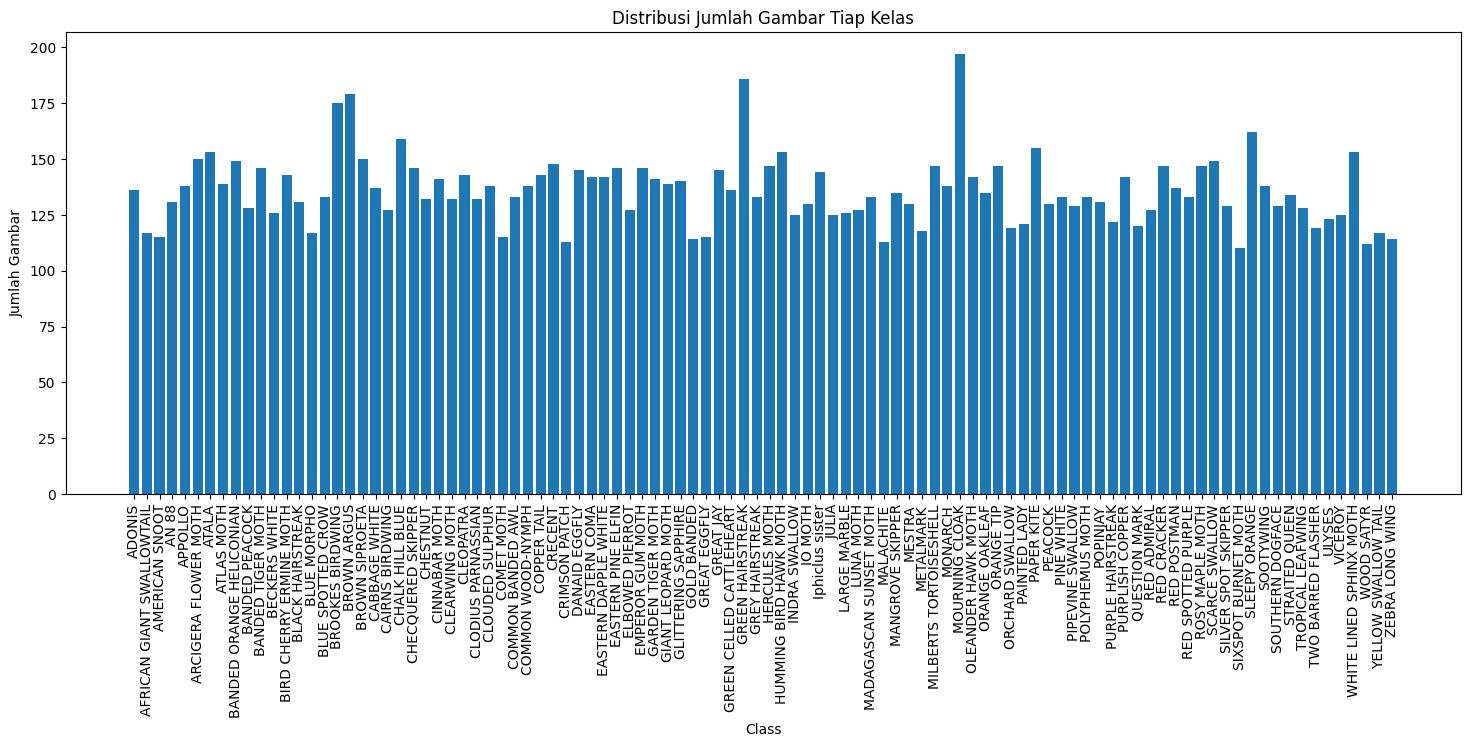

In [4]:
# VISUALISASI DISTRIBUSI DATASET

import matplotlib.pyplot as plt

plt.figure(figsize=(18,6))
plt.bar(
    distribution_df["Class"],
    distribution_df["Total"]
)
plt.xticks(rotation=90)
plt.title("Distribusi Jumlah Gambar Tiap Kelas")
plt.xlabel("Class")
plt.ylabel("Jumlah Gambar")
plt.show()

In [5]:
# DATA PREPROCESSING & DATA AUGMENTATION (tahap 2)
# IMPORT LIBRARY & MEMILIH 20 KELAS PERTAMA
import os
import shutil

# Folder dataset asli
dataset_path = "/content/drive/MyDrive/UAS_VANISSA-KBL91/UAS-kaggel"

train_dir = os.path.join(dataset_path, "train")
valid_dir = os.path.join(dataset_path, "valid")
test_dir  = os.path.join(dataset_path, "test")

# Folder dataset baru (20 kelas)
selected_dataset = "/content/butterfly_dataset_20"

train_selected = os.path.join(selected_dataset, "train")
valid_selected = os.path.join(selected_dataset, "valid")
test_selected  = os.path.join(selected_dataset, "test")

# Hapus folder lama jika ada
if os.path.exists(selected_dataset):
    shutil.rmtree(selected_dataset)

# Buat folder baru
os.makedirs(train_selected)
os.makedirs(valid_selected)
os.makedirs(test_selected)

# Ambil 20 kelas pertama (urut alfabet)
selected_classes = sorted(os.listdir(train_dir))[:20]

# Salin seluruh isi folder
for cls in selected_classes:
    shutil.copytree(
        os.path.join(train_dir, cls),
        os.path.join(train_selected, cls)
    )
    shutil.copytree(
        os.path.join(valid_dir, cls),
        os.path.join(valid_selected, cls)
    )
    shutil.copytree(
        os.path.join(test_dir, cls),
        os.path.join(test_selected, cls)
    )

print("=" * 50)
print("DATASET BERHASIL DIBUAT")
print("=" * 50)
print("Jumlah kelas :", len(selected_classes))
print()
print("Daftar kelas yang digunakan:")
for i, cls in enumerate(selected_classes, start=1):
    print(f"{i}. {cls}")

print("=" * 50)

DATASET BERHASIL DIBUAT
Jumlah kelas : 20

Daftar kelas yang digunakan:
1. ADONIS
2. AFRICAN GIANT SWALLOWTAIL
3. AMERICAN SNOOT
4. AN 88
5. APPOLLO
6. ARCIGERA FLOWER MOTH
7. ATALA
8. ATLAS MOTH
9. BANDED ORANGE HELICONIAN
10. BANDED PEACOCK
11. BANDED TIGER MOTH
12. BECKERS WHITE
13. BIRD CHERRY ERMINE MOTH
14. BLACK HAIRSTREAK
15. BLUE MORPHO
16. BLUE SPOTTED CROW
17. BROOKES BIRDWING
18. BROWN ARGUS
19. BROWN SIPROETA
20. CABBAGE WHITE


In [6]:
# MEMBUAT IMAGE DATA GENERATOR (tahap 3)
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Ukuran gambar
IMG_SIZE = (224, 224)

# Batch size
BATCH_SIZE = 32

# Data Generator
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

valid_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)
print("ImageDataGenerator berhasil dibuat.")

ImageDataGenerator berhasil dibuat.


In [7]:
# MEMBACA DATASET
train_generator = train_datagen.flow_from_directory(
    train_selected,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)
validation_generator = valid_datagen.flow_from_directory(
    valid_selected,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)
test_generator = test_datagen.flow_from_directory(
    test_selected,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print("="*50)
print("DATASET BERHASIL DIMUAT")
print("="*50)
print("Jumlah kelas :", train_generator.num_classes)
print("Jumlah data train :", train_generator.samples)
print("Jumlah data valid :", validation_generator.samples)
print("Jumlah data test :", test_generator.samples)

Found 2593 images belonging to 20 classes.
Found 100 images belonging to 20 classes.
Found 100 images belonging to 20 classes.
DATASET BERHASIL DIMUAT
Jumlah kelas : 20
Jumlah data train : 2593
Jumlah data valid : 100
Jumlah data test : 100


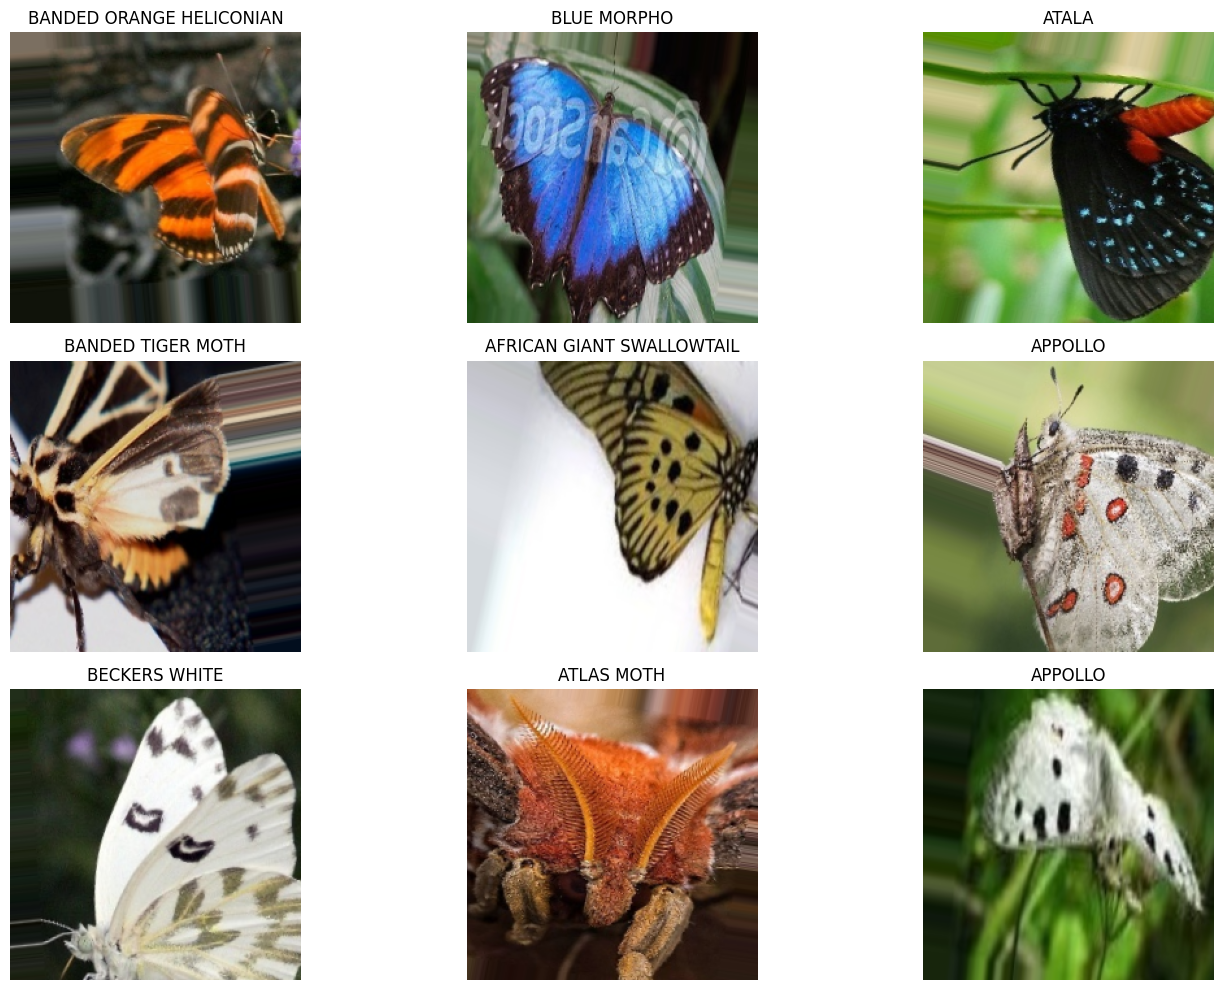

In [8]:
# MENAMPILKAN CONTOH DATA TRAINING
import matplotlib.pyplot as plt
images, labels = next(train_generator)
plt.figure(figsize=(15,10))

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(images[i])
    plt.title(list(train_generator.class_indices.keys())[labels[i].argmax()])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [9]:
# MEMBUAT MODEL TRANSFER LEARNING MOBILENET-V2 (tahap 4)
from tensorflow.keras.applications import MobileNetV2

base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

# Membekukan seluruh layer MobileNetV2
base_model.trainable = False
print("="*50)
print("MobileNetV2 berhasil dimuat.")
print("Jumlah Layer :", len(base_model.layers))
print("="*50)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
MobileNetV2 berhasil dimuat.
Jumlah Layer : 154


In [10]:
# MEMBANGUN MODEL CNN + MOBILENETV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    GlobalAveragePooling2D,
    Dense,
    Dropout,
    BatchNormalization
)

model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    BatchNormalization(),
    Dense(256,activation='relu'),
    Dropout(0.4),
    Dense(train_generator.num_classes,activation='softmax')
])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 20)             │         5,140 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,596,180 (9.90 MB)

 Trainable params: 335,636 (1.28 MB)

 Non-trainable params: 2,260,544 (8.62 MB)

In [11]:
# COMPILE MODEL
from tensorflow.keras.optimizers import Adam
model.compile(
    optimizer=Adam(
        learning_rate=0.0001
    ),
    loss='categorical_crossentropy',
    metrics=['accuracy']

)
print("="*50)
print("Model berhasil di-compile.")
print("="*50)

Model berhasil di-compile.


In [12]:
# CALLBACK
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    ReduceLROnPlateau
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=2,
    min_lr=1e-6,
    verbose=1
)
checkpoint = ModelCheckpoint(
    "best_butterfly_model.keras",
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)
print("Callback berhasil dibuat.")

Callback berhasil dibuat.


In [13]:
# PROSES PELATIHAN MODEL (tahap 5)
# TRAINING MODEL

history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=30,
    callbacks=[
        early_stop,
        reduce_lr,
        checkpoint
    ],
    verbose=1
)
print("="*50)
print("TRAINING SELESAI")
print("="*50)

Epoch 1/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.1569 - loss: 3.2783
Epoch 1: val_accuracy improved from None to 0.65000, saving model to best_butterfly_model.keras

Epoch 1: finished saving model to best_butterfly_model.keras
82/82 ━━━━━━━━━━━━━━━━━━━━ 159s 2s/step - accuracy: 0.2765 - loss: 2.6495 - val_accuracy: 0.6500 - val_loss: 1.6891 - learning_rate: 1.0000e-04
Epoch 2/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5721 - loss: 1.4605
Epoch 2: val_accuracy improved from 0.65000 to 0.81000, saving model to best_butterfly_model.keras

Epoch 2: finished saving model to best_butterfly_model.keras
82/82 ━━━━━━━━━━━━━━━━━━━━ 155s 2s/step - accuracy: 0.6240 - loss: 1.2961 - val_accuracy: 0.8100 - val_loss: 0.9262 - learning_rate: 1.0000e-04
Epoch 3/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7524 - loss: 0.8997
Epoch 3: val_accuracy improved from 0.81000 to 0.87000, saving model to best_butterfly_model.keras

Epoch 3: finished saving model to best_butte

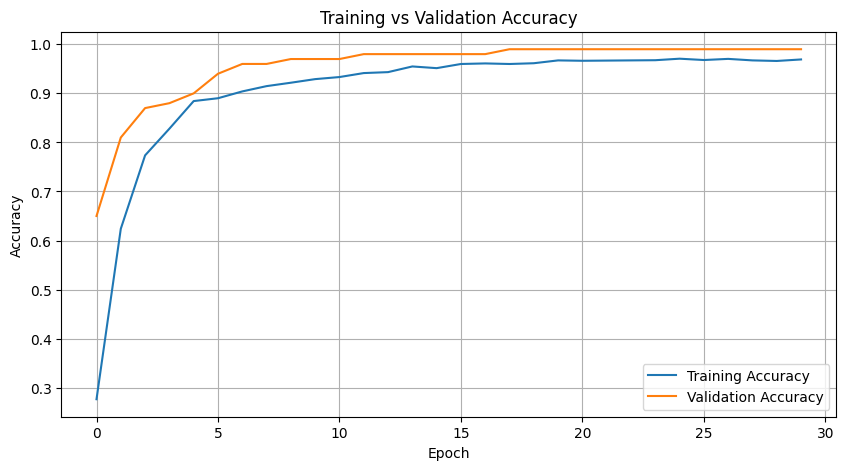

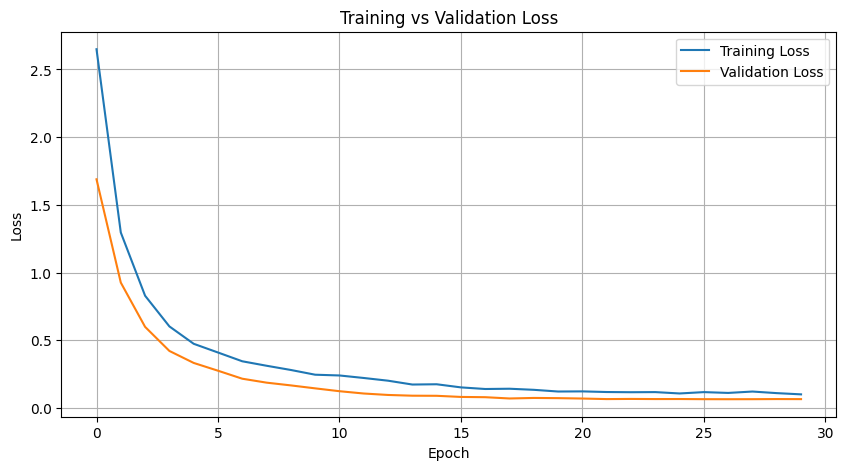

HASIL AKHIR TRAINING
Training Accuracy   : 0.9691
Validation Accuracy : 0.9900

Training Loss       : 0.1011
Validation Loss     : 0.0658


In [14]:
# VISUALISASI HASIL TRAINING (tahap 6)
import matplotlib.pyplot as plt

# Accuracy
plt.figure(figsize=(10,5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

# Loss
plt.figure(figsize=(10,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

# Nilai akhir
print("="*50)
print("HASIL AKHIR TRAINING")
print("="*50)
print(f"Training Accuracy   : {history.history['accuracy'][-1]:.4f}")
print(f"Validation Accuracy : {history.history['val_accuracy'][-1]:.4f}")
print()
print(f"Training Loss       : {history.history['loss'][-1]:.4f}")
print(f"Validation Loss     : {history.history['val_loss'][-1]:.4f}")
print("="*50)

In [15]:
# EVALUASI MODEL MENGGUNAKAN DATA TEST (tahap 7)

print("="*50)
print("EVALUASI MODEL PADA DATA TEST")
print("="*50)

test_loss, test_accuracy = model.evaluate(test_generator, verbose=1)

print("\n")
print("="*50)
print(f"Test Accuracy : {test_accuracy:.4f}")
print(f"Test Loss     : {test_loss:.4f}")
print("="*50)

EVALUASI MODEL PADA DATA TEST
4/4 ━━━━━━━━━━━━━━━━━━━━ 4s 869ms/step - accuracy: 0.9800 - loss: 0.0911


Test Accuracy : 0.9800
Test Loss     : 0.0911


4/4 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step


<Figure size 1200x1200 with 0 Axes>

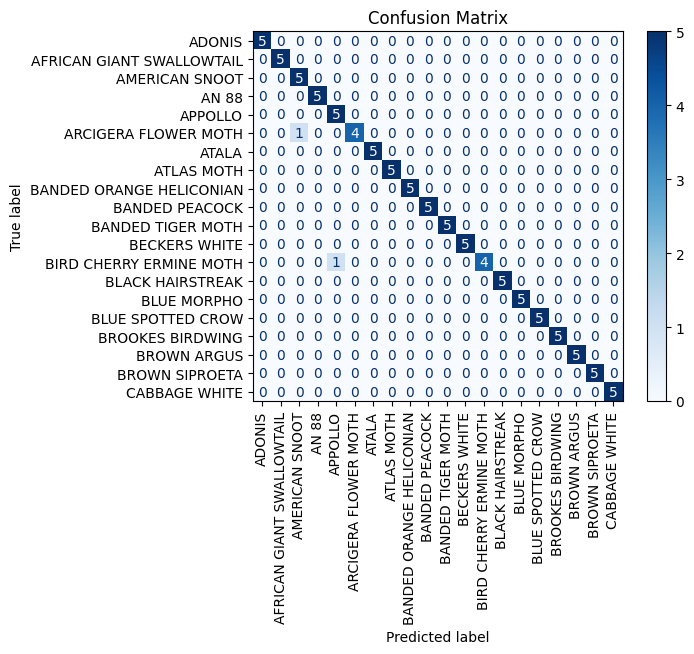

In [16]:
# CONFUSION MATRIX (tahap 8)

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Reset generator
test_generator.reset()

# Prediksi seluruh data test
predictions = model.predict(test_generator)

# Ambil kelas hasil prediksi
y_pred = np.argmax(predictions, axis=1)

# Label sebenarnya
y_true = test_generator.classes

# Nama kelas
class_names = list(test_generator.class_indices.keys())

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

# Tampilkan
plt.figure(figsize=(12,12))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)
disp.plot(
    xticks_rotation=90,
    cmap="Blues",
    values_format='d'
)
plt.title("Confusion Matrix")
plt.show()

In [17]:
# CLASSIFICATION REPORT (tahap 9)

from sklearn.metrics import classification_report
import pandas as pd

# Reset generator
test_generator.reset()

# Prediksi data test
predictions = model.predict(test_generator, verbose=1)
y_pred = np.argmax(predictions, axis=1)
y_true = test_generator.classes

# Nama kelas
class_names = list(test_generator.class_indices.keys())

# Classification Report
report = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    output_dict=True
)

# Ubah menjadi DataFrame agar rapi
report_df = pd.DataFrame(report).transpose()
print("="*60)
print("CLASSIFICATION REPORT")
print("="*60)
display(report_df.round(4))

4/4 ━━━━━━━━━━━━━━━━━━━━ 4s 796ms/step
CLASSIFICATION REPORT


,precision,recall,f1-score,support
ADONIS,1.0000,1.00,1.0000,5.00
AFRICAN GIANT SWALLOWTAIL,1.0000,1.00,1.0000,5.00
AMERICAN SNOOT,0.8333,1.00,0.9091,5.00
AN 88,1.0000,1.00,1.0000,5.00
APPOLLO,0.8333,1.00,0.9091,5.00
ARCIGERA FLOWER MOTH,1.0000,0.80,0.8889,5.00
ATALA,1.0000,1.00,1.0000,5.00
ATLAS MOTH,1.0000,1.00,1.0000,5.00
BANDED ORANGE HELICONIAN,1.0000,1.00,1.0000,5.00
BANDED PEACOCK,1.0000,1.00,1.0000,5.00


UPLOAD GAMBAR KUPU-KUPU


Saving images.jpg to images.jpg


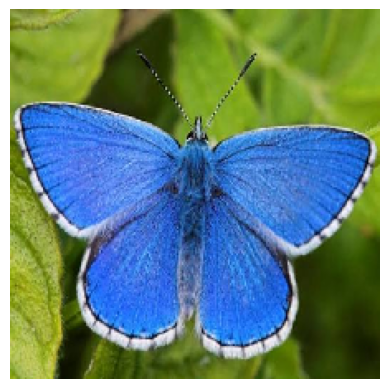

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
HASIL PREDIKSI
Jenis Kupu-kupu : ADONIS
Tingkat Keyakinan : 100.00%


In [18]:
# PREDIKSI GAMBAR BARU (tahap 10)

import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import load_model
from google.colab import files
print("="*50)
print("UPLOAD GAMBAR KUPU-KUPU")
print("="*50)
uploaded = files.upload()
img_path = list(uploaded.keys())[0]

# Load gambar
img = image.load_img(img_path, target_size=(224,224))

# Tampilkan gambar
plt.imshow(img)
plt.axis('off')
plt.show()

# Preprocessing
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = img_array / 255.0

# Prediksi
prediction = model.predict(img_array)
predicted_class = np.argmax(prediction)
confidence = np.max(prediction)
class_names = list(train_generator.class_indices.keys())
print("="*50)
print("HASIL PREDIKSI")
print("="*50)
print(f"Jenis Kupu-kupu : {class_names[predicted_class]}")
print(f"Tingkat Keyakinan : {confidence*100:.2f}%")
print("="*50)

In [19]:
# MENYIMPAN LABEL KELAS (tahap 11)
import json

# Ambil nama kelas
class_names = list(train_generator.class_indices.keys())

# Simpan ke file JSON
with open("class_names.json", "w") as f:
    json.dump(class_names, f)

print("="*50)
print("LABEL KELAS BERHASIL DISIMPAN")
print("="*50)
print("Nama file : class_names.json")
print(f"Jumlah kelas : {len(class_names)}")

LABEL KELAS BERHASIL DISIMPAN
Nama file : class_names.json
Jumlah kelas : 20


In [20]:
# MEMUAT MODEL TERBAIK (tahap 12)

from tensorflow.keras.models import load_model

# Memuat model terbaik
best_model = load_model("best_butterfly_model.keras")

print("="*50)
print("MODEL TERBAIK BERHASIL DIMUAT")
print("="*50)
print("Nama File : best_butterfly_model.keras")
print("Status    : Siap digunakan untuk Website Flask")
print("="*50)

MODEL TERBAIK BERHASIL DIMUAT
Nama File : best_butterfly_model.keras
Status    : Siap digunakan untuk Website Flask


In [22]:
# MENYIMPAN FILE KE GOOGLE DRIVE

import shutil
import os
save_folder = "/content/drive/MyDrive/UAS_VANISSA-KBL91/UAS_AI_Butterfly"
os.makedirs(save_folder, exist_ok=True)
shutil.copy("best_butterfly_model.keras", save_folder)
shutil.copy("class_names.json", save_folder)

print("="*50)
print("SEMUA FILE BERHASIL DISIMPAN")
print("="*50)
print(f"Lokasi : {save_folder}")
print("✔ best_butterfly_model.keras")
print("✔ class_names.json")
print("="*50)

SEMUA FILE BERHASIL DISIMPAN
Lokasi : /content/drive/MyDrive/UAS_VANISSA-KBL91/UAS_AI_Butterfly
✔ best_butterfly_model.keras
✔ class_names.json


In [23]:
# RINGKASAN MODEL
print("="*60)
print("RINGKASAN MODEL")
print("="*60)

best_model.summary()

RINGKASAN MODEL


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 20)             │         5,140 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,267,454 (12.46 MB)

 Trainable params: 335,636 (1.28 MB)

 Non-trainable params: 2,260,544 (8.62 MB)

 Optimizer params: 671,274 (2.56 MB)

In [24]:
# KESIMPULAN
print("="*60)
print("KESIMPULAN")
print("="*60)
print(f"Jumlah kelas                : {len(class_names)}")
print(f"Training Accuracy           : {history.history['accuracy'][-1]:.4f}")
print(f"Validation Accuracy         : {history.history['val_accuracy'][-1]:.4f}")
print(f"Test Accuracy               : {test_accuracy:.4f}")
print(f"Training Loss               : {history.history['loss'][-1]:.4f}")
print(f"Validation Loss             : {history.history['val_loss'][-1]:.4f}")
print(f"Test Loss                   : {test_loss:.4f}")
print("\nModel berhasil dilatih menggunakan MobileNetV2")
print("dan siap diimplementasikan pada aplikasi web Flask.")
print("="*60)

KESIMPULAN
Jumlah kelas                : 20
Training Accuracy           : 0.9691
Validation Accuracy         : 0.9900
Test Accuracy               : 0.9800
Training Loss               : 0.1011
Validation Loss             : 0.0658
Test Loss                   : 0.0911

Model berhasil dilatih menggunakan MobileNetV2
dan siap diimplementasikan pada aplikasi web Flask.
